In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1Set base directory and data directory
base_dir = os.getcwd()               
data_dir = os.path.join(base_dir, "Data")  

# 2Load O*NET task data
task_file = os.path.join(data_dir, "onet_tasks.csv")
task_data = pd.read_csv(task_file)

# Load Eurostat ISCO sheets dynamically
isco_file = os.path.join(data_dir, "Eurostat_employment_isco.xlsx")
isco_data = {i: pd.read_excel(isco_file, sheet_name=f"ISCO{i}") for i in range(1, 10)}

# Function to compute total employment per country
def compute_total(country):
    return sum(df[country] for df in isco_data.values())

# Compute totals
total_Belgium = compute_total("Belgium")
total_Spain = compute_total("Spain")
total_Poland = compute_total("Poland")

print("Totals computed successfully!")

Totals computed successfully!


In [14]:
# Add ISCO labels dynamically
for i, df in isco_data.items():
    df['ISCO'] = i

# Concatenate all datasets
all_data = pd.concat(isco_data.values(), ignore_index=True)

# List of countries
countries = ["Belgium", "Spain", "Poland"]

# Compute totals directly from all_data (no need to pre-create total_* variables)
totals = all_data.groupby(all_data.index // 9)[countries].sum()

# Repeat totals to match original dataframe length
totals_expanded = pd.concat([totals]*9, ignore_index=True)

# Add totals to dataframe
for country in countries:
    all_data[f"total_{country}"] = totals_expanded[country]

# Compute shares
for country in countries:
    all_data[f"share_{country}"] = all_data[country] / all_data[f"total_{country}"]
    

In [ ]:
# Extract first digit of ISCO code
task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

# Calculate mean task values at 1-digit ISCO level
aggdata = task_data.groupby("isco08_1dig").mean().drop(columns=["isco08"])

# Merge with the main dataset
combined = pd.merge(
    all_data, 
    aggdata, 
    left_on='ISCO', 
    right_on='isco08_1dig', 
    how='left'
)

In [16]:
import numpy as np

# List of task columns
task_cols = ["t_4A2a4", "t_4A2b2", "t_4A4a1"]

# List of countries
countries = ["Belgium", "Poland", "Spain"]

# Loop over tasks and countries to compute weighted standardized values
for task in task_cols:
    for country in countries:
        weights = combined[f"share_{country}"]
        w_mean = np.average(combined[task], weights=weights)
        w_sd = np.sqrt(np.average((combined[task] - w_mean)**2, weights=weights))
        combined[f"std_{country}_{task}"] = (combined[task] - w_mean) / w_sd

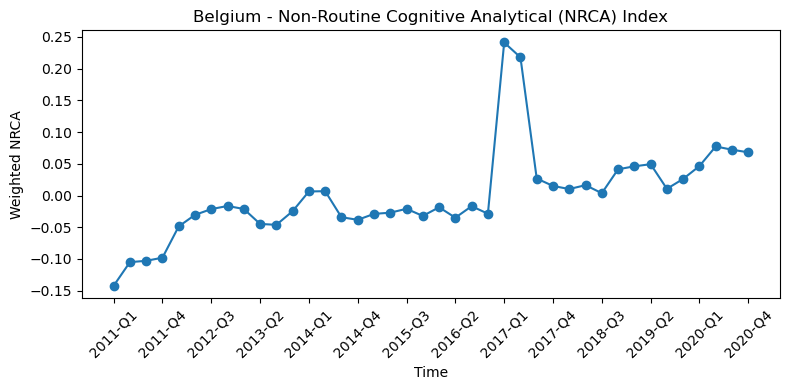

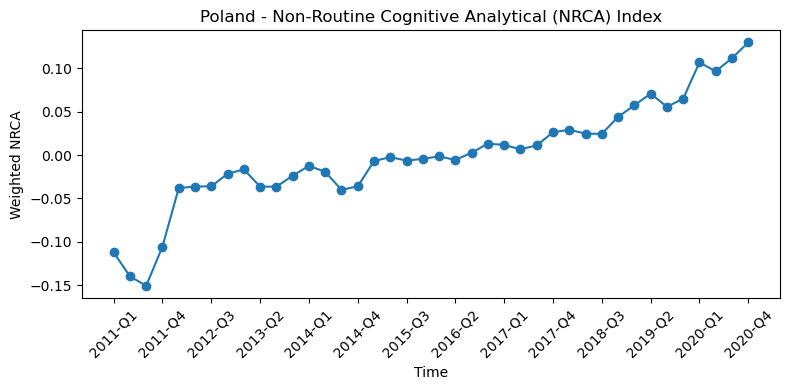

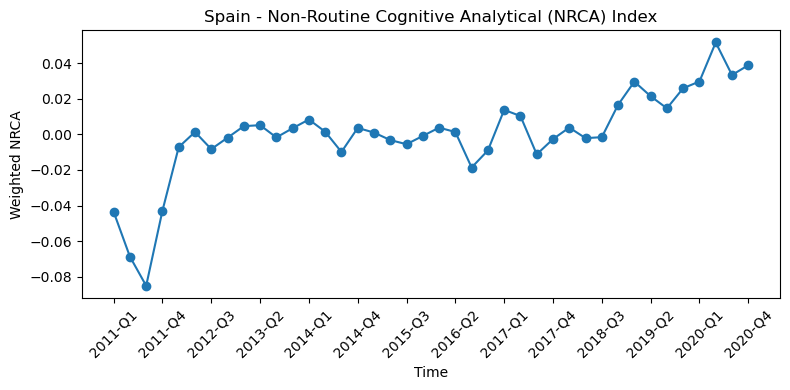

In [17]:
# List of countries
countries = ["Belgium", "Poland", "Spain"]

# List of standardized task columns for NRCA
tasks_std = {
    country: [f"std_{country}_t_4A2a4",
              f"std_{country}_t_4A2b2",
              f"std_{country}_t_4A4a1"]
    for country in countries
}

# Step 1: Calculate NRCA by summing standardized task columns
for country in countries:
    combined[f"{country}_NRCA"] = combined[tasks_std[country]].sum(axis=1)
    
    # Step 2: Standardize NRCA weighted by employment share
    w = combined[f"share_{country}"]
    mean = np.average(combined[f"{country}_NRCA"], weights=w)
    std = np.sqrt(np.average((combined[f"{country}_NRCA"] - mean)**2, weights=w))
    combined[f"std_{country}_NRCA"] = (combined[f"{country}_NRCA"] - mean) / std
    
    # Step 3: Multiply by share to get weighted contribution
    combined[f"multip_{country}_NRCA"] = combined[f"std_{country}_NRCA"] * w

# Step 4: Aggregate by TIME
agg_dict = {}
for country in countries:
    agg_dict[country] = combined.groupby("TIME")[f"multip_{country}_NRCA"].sum().reset_index()

# Step 5: Plot for each country
for country in countries:
    plt.figure(figsize=(8,4))
    plt.plot(agg_dict[country]["TIME"], agg_dict[country][f"multip_{country}_NRCA"], marker='o')
    plt.title(f"{country} - Non-Routine Cognitive Analytical (NRCA) Index")
    plt.xlabel("Time")
    plt.ylabel("Weighted NRCA")
    plt.xticks(range(0, len(agg_dict[country]), 3), agg_dict[country]["TIME"][::3], rotation=45)
    plt.tight_layout()
    plt.show()